# Chromatin PTR analysis
March 18, 2024

Simple PTR analysis to compare deconvolved PTR to raw PTR.

Then compare deconvolved PTR to gene expression deconvovled PTR.


In [48]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
import glob

outdir = 'output/deconvolve_combined_g_opt_2024_03_14/chromatin/'

from cc_src.peak_to_trough_anaysis import PeakToTroughAnalysis

peak_to_trough_analysis = PeakToTroughAnalysis(outdir)


## Evaluating different metrics to summarize gene PTR's

Next, we will evaluate other metrics that can capture a larger summary of the PTR image per gene. 

Metrics:
- Mean
- Median
- Quantiles: 80, 20

Evaluation:
- Plot a set of 20 genes and their PTR images, and evaluate how each metric measures up per gene.


In [50]:
peak_to_trough_analysis.compute_summary_metrics()

In [63]:
peak_to_trough_analysis.load_Fourier_scores()

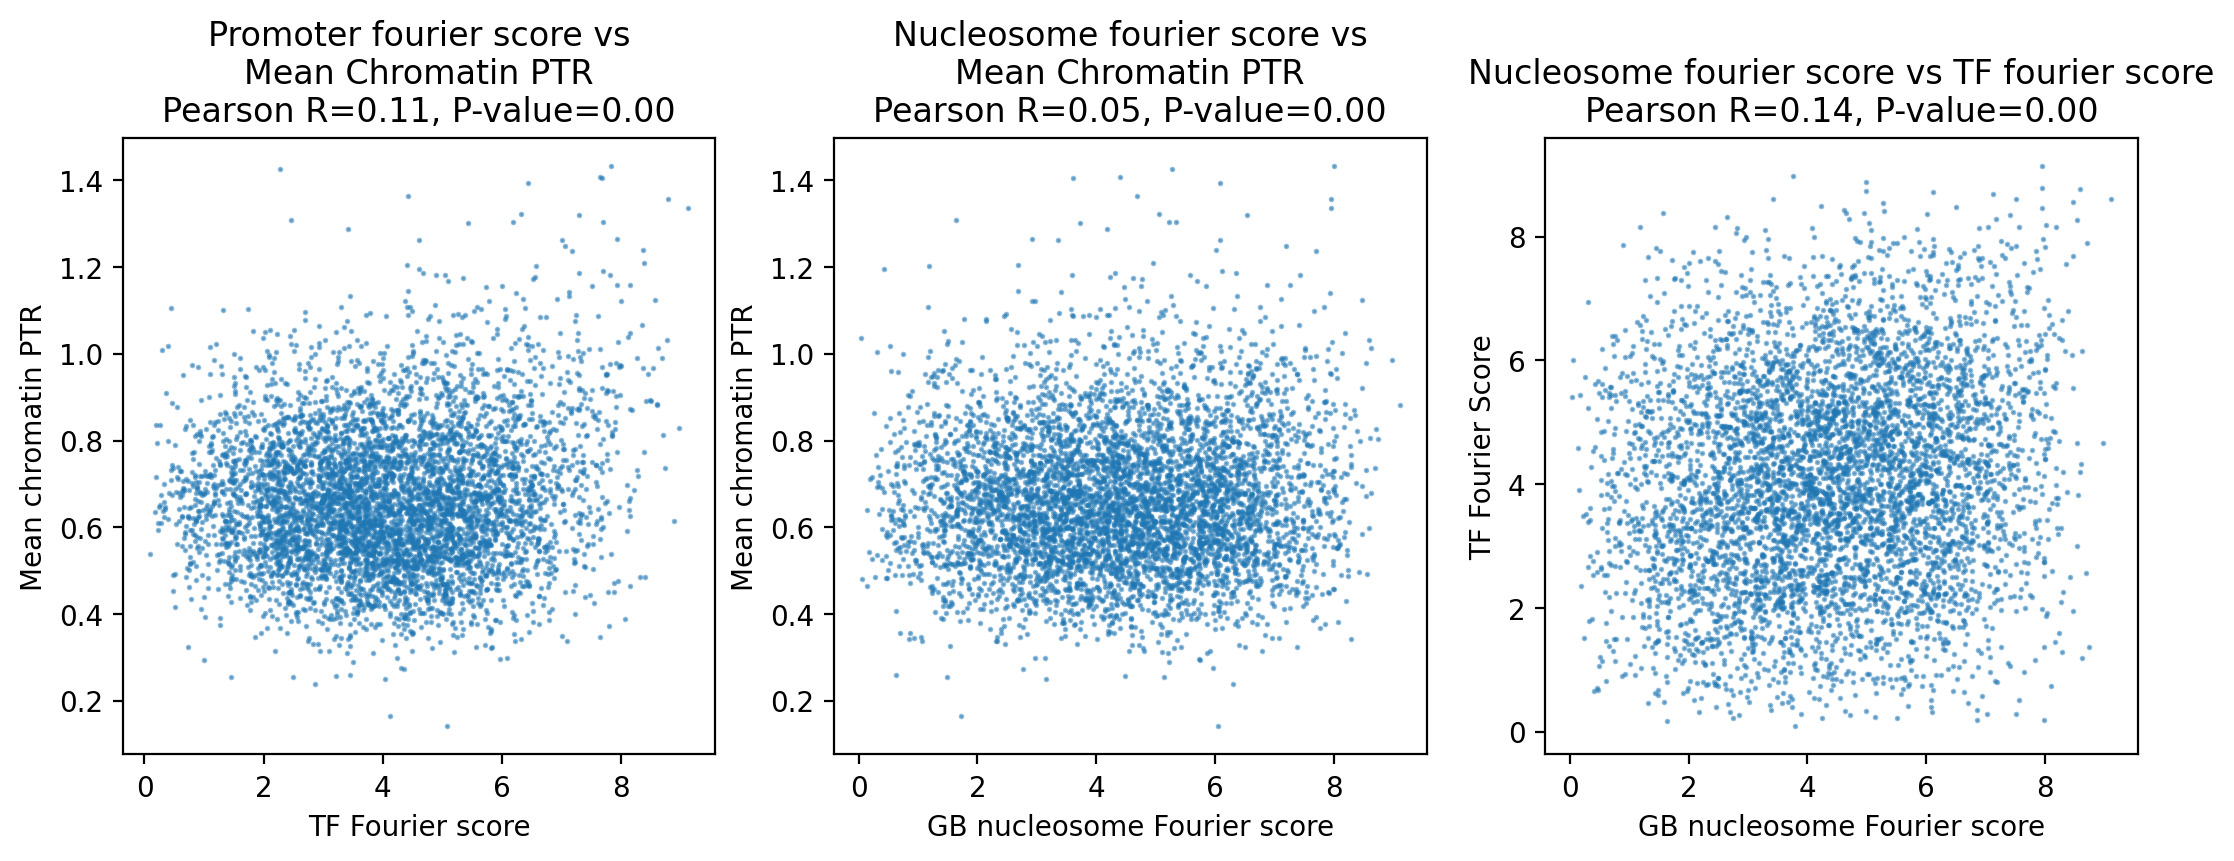

In [66]:
peak_to_trough_analysis.plot_ptr_comparison_to_fourier()

In [152]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel

def compute_g_ptr(gene_name, replicate):
    config1 = load_yl_rg1_vst_config(replicate)

    chromatin_model1 = ChromatinModel(config1)
    chromatin_model1.load_mnase_gene(gene_name, log=False)
    chromatin_model1.create_deconvolution_bins()

    # Compute the raw PTR for the gene for both replicates
    from cc_src.peak_to_trough import compute_quantile_ptr

    mu0 = config1.intervals_wt1[0][0]

    # Compute the peak to trough ratio for non recovery timepoints
    non_RG1_G = chromatin_model1.G[chromatin_model1.timepoints > mu0, :]
    g_ptrs = np.apply_along_axis(lambda mat: compute_quantile_ptr(mat, 
        0.2, 0.8), 0, non_RG1_G)
    return g_ptrs


In [159]:
from src.timer import Timer
from cc_src.reference_data import load_analysis_genes

def get_g_ptrs_replicate(replicate):
    timer = Timer()
    
    geneset = load_analysis_genes()
    g_ptrs_df = None

    i = 0
    for orf_name, gene in geneset.iterrows():
        current_g_ptrs = compute_g_ptr(orf_name, replicate)

        if g_ptrs_df is None:        
            g_ptrs_df = pd.DataFrame(index=geneset.index.values,
                columns=np.arange(current_g_ptrs.shape[0]))

        g_ptrs_df.loc[orf_name, :] = current_g_ptrs

        if i % 100 == 0:
            print(f"{i}/{len(geneset)} - {timer.get_time()}")

        i += 1
        
        if i == 10: break
        
    return g_ptrs_df


In [165]:
g_ptrs_1_df = get_g_ptrs_replicate(1)

0/5578 - 00:00:01.46


In [166]:
g_ptrs_1_df.to_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep1.csv')

In [167]:
g_ptrs_2_df = get_g_ptrs_replicate(2)

0/5578 - 00:00:01.49


In [168]:
g_ptrs_2_df.to_csv('output/raw_g_ptrs/g_ptrs_chromatin_rep2.csv')